# Triggo AI teste técnico

#### Objetivo: 
#### analisar o conjunto de dados históricos de vendas para extrair insights valiosos que possam ajudar nas decisões estratégicas do negócio.

## 1. Preparação dos Dados

In [20]:
import seaborn as sb
import numpy as np
import matplotlib as mlib
import pandas as pd
import sqlite3

In [21]:
%load_ext sql
%sql sqlite:///olist.db

The sql extension is already loaded. To reload it, use:
  %reload_ext sql


In [22]:
#verificando o diretório do anaconda 
import os 
os.getcwd()

'C:\\Users\\SCardos4'

In [23]:
#lendo arquivos csv com pandas

orders_df = pd.read_csv("KaggleOli\olist_orders_dataset.csv")
order_items_df = pd.read_csv("KaggleOli\olist_order_items_dataset.csv")
customers_df = pd.read_csv("KaggleOli\olist_customers_dataset.csv")
products_df = pd.read_csv("KaggleOli\olist_products_dataset.csv")
sellers_df = pd.read_csv("KaggleOli\olist_sellers_dataset.csv")
payments_df = pd.read_csv("KaggleOli\olist_order_payments_dataset.csv")
reviews_df = pd.read_csv("KaggleOli\olist_order_reviews_dataset.csv")
geolocation_df = pd.read_csv("KaggleOli\olist_geolocation_dataset.csv")
category_translation_df = pd.read_csv("KaggleOli\product_category_name_translation.csv")


In [24]:
orders_df.head(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [25]:
orders_df.tail(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00
99440,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-03-08 20:57:30,2018-03-09 11:20:28,2018-03-09 22:11:59,2018-03-16 13:08:30,2018-04-03 00:00:00


In [26]:
def visualizacao(dicionario_dfs, linhas=3):
    for nome, df in dicionario_dfs.items():
        print(f"{nome} — {df.shape[0]} linhas x {df.shape[1]} colunas")
        display(df.head(linhas))
        print("-" * 80)

dataframes = {
    "orders": orders_df,
    "order_items": order_items_df,
    "customers": customers_df,
    "products": products_df,
    "sellers": sellers_df,
    "payments": payments_df,
    "reviews": reviews_df,
    "geolocation": geolocation_df,
    "category_translation": category_translation_df
}

visualizacao(dataframes)

orders — 99441 linhas x 8 colunas


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00


--------------------------------------------------------------------------------
order_items — 112650 linhas x 7 colunas


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.9,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.0,17.87


--------------------------------------------------------------------------------
customers — 99441 linhas x 5 colunas


...

--------------------------------------------------------------------------------
geolocation — 1000163 linhas x 5 colunas


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP


--------------------------------------------------------------------------------
category_translation — 71 linhas x 2 colunas


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto


--------------------------------------------------------------------------------


In [27]:
def overview_df(df):
    resumo = pd.DataFrame({
        "Tipo": df.dtypes,
        "Nulos (%)": df.isnull().mean() * 100,
        "Valores Unicos": df.nunique(),
        "Exemplo": df.iloc[0]
    })
    return resumo.sort_values("Nulos (%)", ascending=False)

In [28]:
overview_df(category_translation_df)
overview_df(order_items_df)
overview_df(orders_df)
overview_df(customers_df)
overview_df(sellers_df)    

,Tipo,Nulos (%),Valores Unicos,Exemplo
seller_id,object,0.0,3095,3442f8959a84dea7ee197c632cb2df15
seller_zip_code_prefix,int64,0.0,2246,13023
seller_city,object,0.0,611,campinas
seller_state,object,0.0,23,SP


In [29]:
sellers_df.head(10)
sellers_df.tail(10)

,seller_id,seller_zip_code_prefix,seller_city,seller_state
3085,9d489893ff6af05029671b785f54b998,13613,leme,SP
3086,725af026f869236a8dd0ceb98564d156,35530,claudio,MG
3087,f00f5b35d0abcacbdd863672f4bb2c1a,1238,sao paulo,SP
3088,7bac63f6603d382cc8d0832eb6c100a8,5713,sao paulo,SP
3089,f1fdf2d13186575751aa25876536d85c,5314,sao paulo,SP
3090,98dddbc4601dd4443ca174359b237166,87111,sarandi,PR
3091,f8201cab383e484733266d1906e2fdfa,88137,palhoca,SC
3092,74871d19219c7d518d0090283e03c137,4650,sao paulo,SP
3093,e603cf3fec55f8697c9059638d6c8eb5,96080,pelotas,RS
3094,9e25199f6ef7e7c347120ff175652c3b,12051,taubate,SP


In [30]:
def diagnostico_df(df):
    print("Shape:", df.shape)
    print(df.dtypes)
    print("\nNulos:")
    print(df.isnull().sum())
    print("\nDuplicatas:", df.duplicated().sum())
    print("-" * 50)

def normalizar_colunas(df):
    for col in df.select_dtypes(include='object').columns:
        df[col] = df[col].astype(str).str.strip().str.lower()
    return df

# Aplicar em todos
dataframes = {
    "orders": orders_df,
    "order_items": order_items_df,
    "customers": customers_df,
    "products": products_df,
    "sellers": sellers_df,
    "payments": payments_df,
    "reviews": reviews_df,
    "geolocation": geolocation_df,
    "category_translation": category_translation_df
}

for nome, df in dataframes.items():
    print(f"\n📋 Diagnóstico: {nome}")
    diagnostico_df(df)
    df.drop_duplicates(inplace=True)
    df = normalizar_colunas(df)
    dataframes[nome] = df  # Atualiza


📋 Diagnóstico: orders
Shape: (99441, 8)
order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

Nulos:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Duplicatas: 0
--------------------------------------------------

📋 Diagnóstico: order_items
Shape: (112650, 7)
order_id                object
order_item_id            int64
product_id              object
seller_id               object
shipping_limit_date     object
price                  float64
f

In [35]:
# Limpar espaços e NaNs nos nomes das colunas
for nome, df in dataframes.items():
    df.columns = df.columns.str.strip()
    df.columns = df.columns.fillna(f"{nome}_coluna_vazia")
    dataframes[nome] = df

In [36]:
conn = sqlite3.connect('olist.db')

for nome, df in dataframes.items():
    df.to_sql(nome, conn, index=False, if_exists='replace')

In [42]:
import sqlite3

# Conexão ao banco
conn = sqlite3.connect("olist.db")

# Dicionário com todos os DataFrames carregados
dataframes = {
    "orders": orders_df,
    "order_items": order_items_df,
    "customers": customers_df,
    "products": products_df,
    "sellers": sellers_df,
    "order_payments": payments_df,
    "order_reviews": reviews_df,
    "geolocation": geolocation_df,
    "product_category": category_translation_df
}

# Salva no banco
for nome, df in dataframes.items():
    df.columns = df.columns.str.lower().str.strip().str.replace(" ", "_")
    df.to_sql(nome, conn, if_exists='replace', index=False)

In [43]:
query = """
DROP TABLE IF EXISTS base_geral;

CREATE TABLE base_geral AS
SELECT 
    o.order_id,
    o.customer_id,
    c.customer_state,
    oi.product_id,
    p.product_category_name,
    pct.product_category_name_english,
    oi.seller_id,
    s.seller_state,
    o.order_purchase_timestamp,
    o.order_delivered_customer_date,
    op.payment_value,
    orr.review_score,
    oi.freight_value,
    oi.price
FROM orders o
LEFT JOIN customers c ON o.customer_id = c.customer_id
LEFT JOIN order_items oi ON o.order_id = oi.order_id
LEFT JOIN products p ON oi.product_id = p.product_id
LEFT JOIN product_category pct ON p.product_category_name = pct.product_category_name
LEFT JOIN sellers s ON oi.seller_id = s.seller_id
LEFT JOIN order_payments op ON o.order_id = op.order_id
LEFT JOIN order_reviews orr ON o.order_id = orr.order_id
WHERE o.order_status = 'delivered';
"""

In [44]:
conn.executescript(query)

In [45]:
df = pd.read_sql('SELECT * FROM base_geral', conn)
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['order_delivered_customer_date'] = pd.to_datetime(df['order_delivered_customer_date'])

## 2. Análise Exploratória 

#### Qual o volume de pedidos por mês? Existe sazonalidade nas vendas?

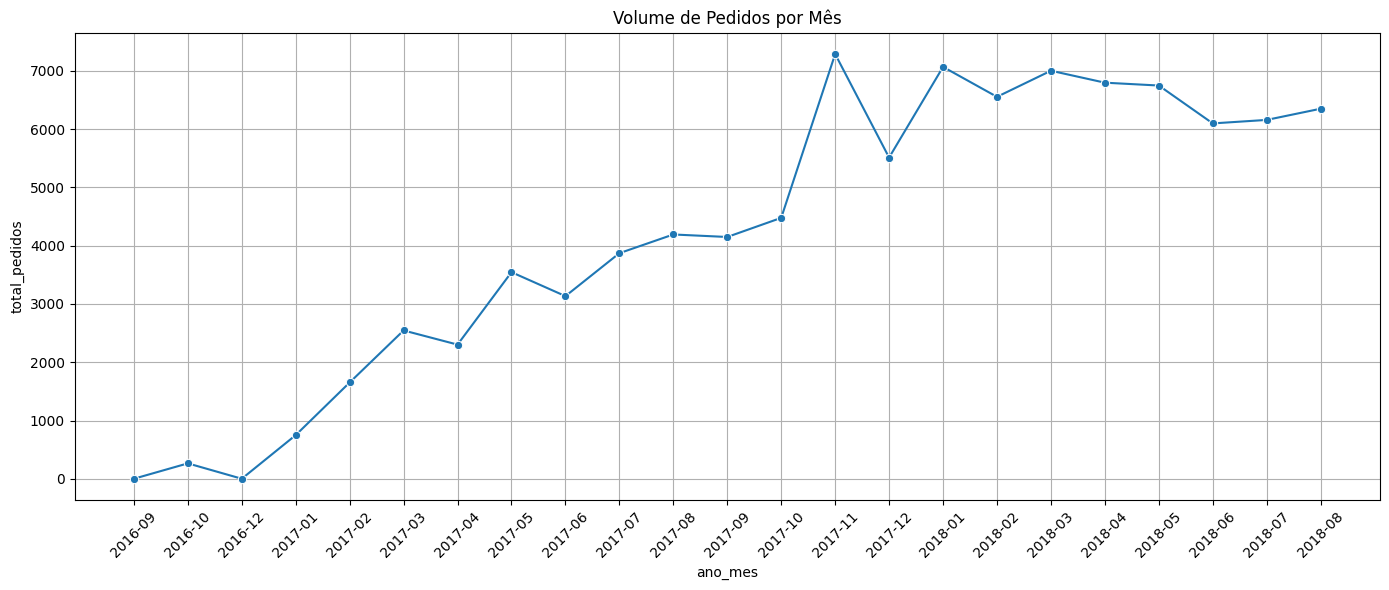

In [46]:
query = """
SELECT 
    strftime('%Y-%m', order_purchase_timestamp) AS ano_mes,
    COUNT(DISTINCT order_id) AS total_pedidos
FROM base_geral
GROUP BY ano_mes
ORDER BY ano_mes;
"""

pedidos_mes = pd.read_sql(query, conn)

# Visualizando
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,6))
sns.lineplot(data=pedidos_mes, x='ano_mes', y='total_pedidos', marker='o')
plt.title('Volume de Pedidos por Mês')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

#### Qual a distribução de tempo de entrega de pedidos?

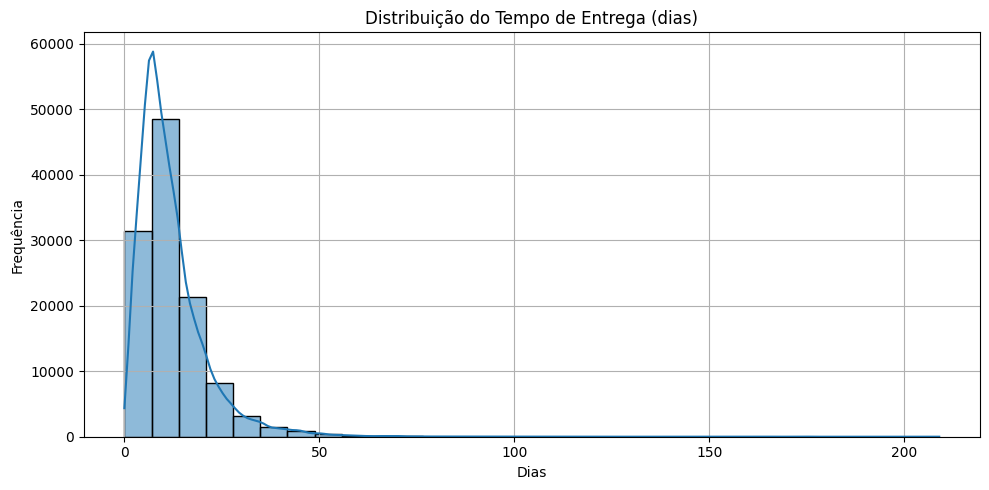

In [47]:
# Convertendo colunas para datetime
base = pd.read_sql("SELECT * FROM base_geral", conn)
base['order_purchase_timestamp'] = pd.to_datetime(base['order_purchase_timestamp'])
base['order_delivered_customer_date'] = pd.to_datetime(base['order_delivered_customer_date'])

# Criando coluna de tempo de entrega
base['tempo_entrega'] = (base['order_delivered_customer_date'] - base['order_purchase_timestamp']).dt.days

# Plotando
plt.figure(figsize=(10,5))
sns.histplot(base['tempo_entrega'].dropna(), bins=30, kde=True)
plt.title('Distribuição do Tempo de Entrega (dias)')
plt.xlabel('Dias')
plt.ylabel('Frequência')
plt.grid(True)
plt.tight_layout()
plt.show()

#### Qual a relação entre o valor do frete e a distância da entrega?

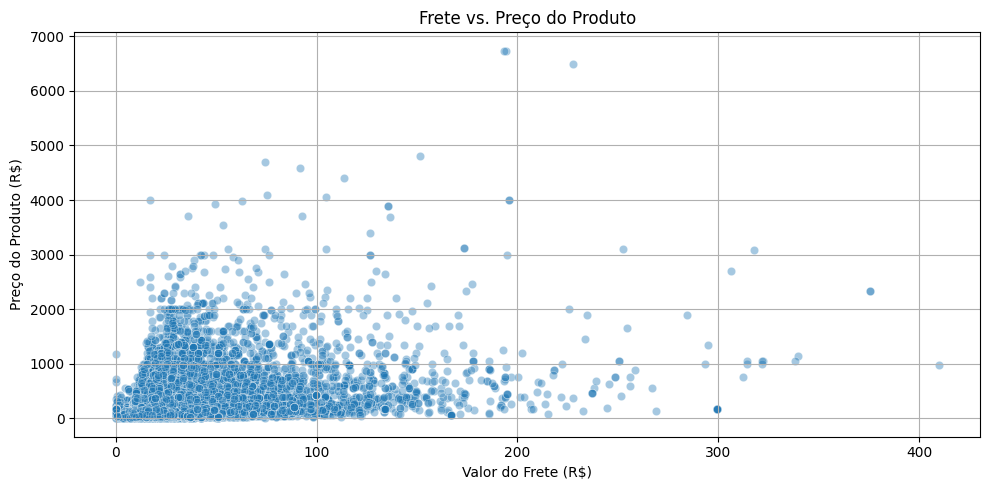

In [48]:
# Scatter plot simples
plt.figure(figsize=(10,5))
sns.scatterplot(data=base, x='freight_value', y='price', alpha=0.4)
plt.title('Frete vs. Preço do Produto')
plt.xlabel('Valor do Frete (R$)')
plt.ylabel('Preço do Produto (R$)')
plt.grid(True)
plt.tight_layout()
plt.show()

#### Quais são as categorias de produtos mais vendidas em termos de faturamento?

C:\Users\SCardos4\AppData\Local\Temp\ipykernel_29904\2395511901.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_categorias, x='faturamento', y='categoria', palette='viridis')


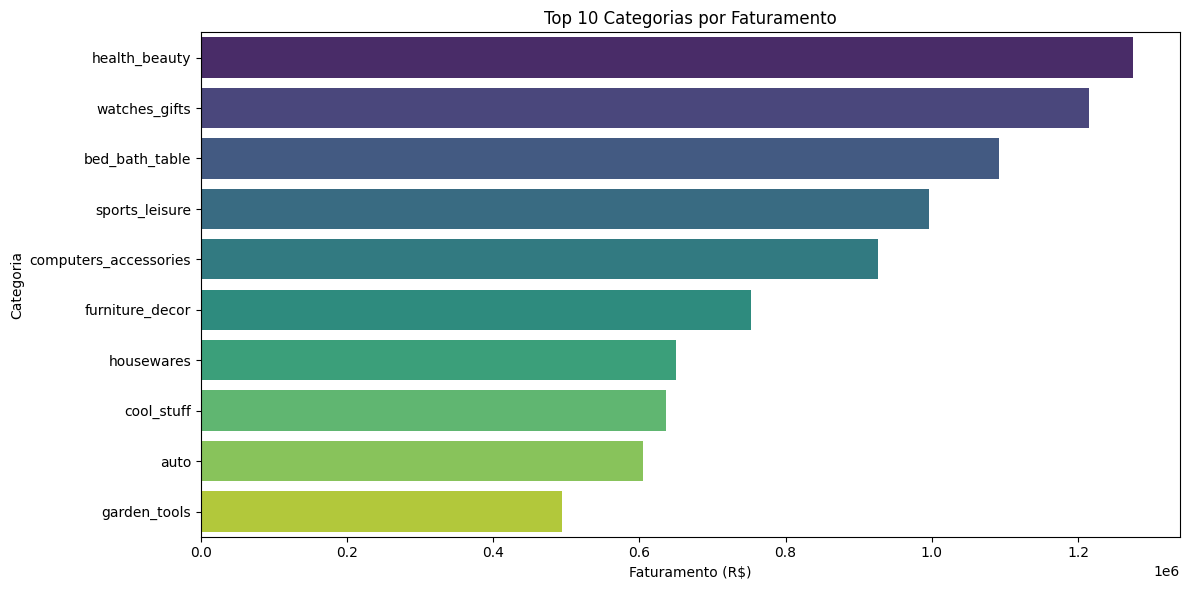

In [49]:
query = """
SELECT 
    product_category_name_english AS categoria,
    ROUND(SUM(price), 2) AS faturamento
FROM base_geral
GROUP BY categoria
ORDER BY faturamento DESC
LIMIT 10;
"""

top_categorias = pd.read_sql(query, conn)

plt.figure(figsize=(12,6))
sns.barplot(data=top_categorias, x='faturamento', y='categoria', palette='viridis')
plt.title('Top 10 Categorias por Faturamento')
plt.xlabel('Faturamento (R$)')
plt.ylabel('Categoria')
plt.tight_layout()
plt.show()

#### Quais estados brasileiros possuem o maior valor médio de pedido?

C:\Users\SCardos4\AppData\Local\Temp\ipykernel_29904\4112822343.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=valor_medio_estado, x='customer_state', y='valor_medio_pedido', palette='coolwarm')


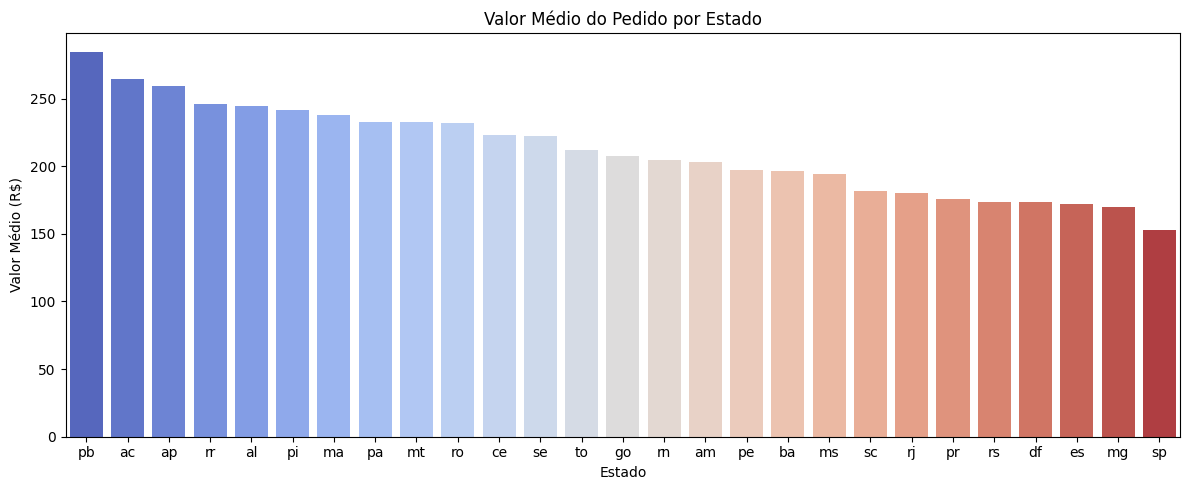

In [50]:
query = """
SELECT 
    customer_state,
    ROUND(AVG(payment_value), 2) AS valor_medio_pedido
FROM base_geral
GROUP BY customer_state
ORDER BY valor_medio_pedido DESC;
"""

valor_medio_estado = pd.read_sql(query, conn)

plt.figure(figsize=(12,5))
sns.barplot(data=valor_medio_estado, x='customer_state', y='valor_medio_pedido', palette='coolwarm')
plt.title('Valor Médio do Pedido por Estado')
plt.xlabel('Estado')
plt.ylabel('Valor Médio (R$)')
plt.tight_layout()
plt.show()

## 3 - Solução de Problemas de Negócio 

In [54]:
query = """
SELECT customer_id, COUNT(DISTINCT order_id) AS qtd_pedidos
FROM base_geral
GROUP BY customer_id;
"""

pedidos_por_cliente = pd.read_sql(query, conn)

# Classificando como recorrente
pedidos_por_cliente['recorrente'] = pedidos_por_cliente['qtd_pedidos'] > 1

# Taxa de recorrência
taxa_recorrencia = pedidos_por_cliente['recorrente'].mean() * 100
print(f"Taxa de clientes recorrentes: {taxa_recorrencia:.2f}%")

Taxa de clientes recorrentes: 0.00%


In [56]:
query = """
SELECT customer_id, COUNT(DISTINCT order_id) AS qtd_pedidos
FROM base_geral
GROUP BY customer_id
ORDER BY qtd_pedidos DESC
LIMIT 10;
"""

pd.read_sql(query, conn)

,customer_id,qtd_pedidos
0,ffffa3172527f765de70084a7e53aae8,1
1,ffff42319e9b2d713724ae527742af25,1
2,fffeda5b6d849fbd39689bb92087f431,1
3,fffecc9f79fd8c764f843e9951b11341,1
4,fffcb937e9dd47a13f05ecb8290f4d3e,1
5,fffb97495f78be80e2759335275df2aa,1
6,fffa0238b217e18a8adeeda0669923a3,1
7,fff93c1da78dafaaa304ff032abc6205,1
8,fff906ecb75de5809be384e0f8d65e45,1
9,fff89c8ed4fcf69a823c1d149e429a0b,1


In [68]:
# retenção

query = """
SELECT customer_id, COUNT(order_id) AS qtd_pedidos
FROM orders
GROUP BY customer_id
"""

clientes = pd.read_sql(query, conn)
clientes['recorrente'] = clientes['qtd_pedidos'] > 1
taxa = clientes['recorrente'].mean() * 100
print(f"Taxa de clientes recorrentes: {taxa:.2f}%")

Taxa de clientes recorrentes: 0.00%


In [57]:
orders_df["customer_id"].nunique(), orders_df["order_id"].nunique()

(99441, 99441)

In [58]:
print(f"Número total de pedidos: {orders_df.shape[0]}")
print(f"Número total de clientes únicos: {orders_df['customer_id'].nunique()}")

Número total de pedidos: 99441
Número total de clientes únicos: 99441


In [59]:
print(f"Quantidade de customer_id nulos: {orders_df['customer_id'].isnull().sum()}")

Quantidade de customer_id nulos: 0


In [60]:
pedidos_por_cliente = orders_df.groupby('customer_id')['order_id'].nunique()
print(pedidos_por_cliente.value_counts().sort_index())

order_id
1    99441
Name: count, dtype: int64


In [61]:
clientes_multiplos = pedidos_por_cliente[pedidos_por_cliente > 1]
print(f"Clientes com mais de um pedido: {len(clientes_multiplos)}")
print(clientes_multiplos.head(10))

Clientes com mais de um pedido: 0
Series([], Name: order_id, dtype: int64)


In [ ]:
## atraso classificação

In [69]:
base['atrasado'] = base['order_delivered_customer_date'] > base['order_purchase_timestamp'] + pd.Timedelta(days=10)
base['atrasado'] = base['atrasado'].astype(int)

In [70]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Seleção de features simples
features = base[['freight_value', 'price', 'payment_value']].fillna(0)
target = base['atrasado']

# Treino e teste
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.3, random_state=42)

# Modelo
modelo = RandomForestClassifier(n_estimators=100, random_state=42)
modelo.fit(X_train, y_train)

# Avaliação
y_pred = modelo.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.73      0.68      0.71     16754
           1       0.72      0.77      0.74     17963

    accuracy                           0.73     34717
   macro avg       0.73      0.73      0.73     34717
weighted avg       0.73      0.73      0.73     34717



In [ ]:
# Correlação com review_score
cols = ['review_score', 'freight_value', 'price', 'payment_value', 'tempo_entrega']
sns.pairplot(base[cols].dropna(), diag_kind="kde")
plt.suptitle('Relacionamentos com Review Score', y=1.02)
plt.show()

In [ ]:
review_categoria = base.groupby('product_category_name_english')['review_score'].mean().sort_values(ascending=False).head(10)
review_categoria.plot(kind='barh', figsize=(10,6), title='Média de Avaliação por Categoria')
plt.xlabel('Review Score Médio')
plt.tight_layout()
plt.show()

## 4 - Visualização

In [62]:
query = "SELECT * FROM base_geral"
base_geral_df = pd.read_sql_query(query, conn)

C:\Users\SCardos4\AppData\Local\Temp\ipykernel_29904\1020159075.py:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  vendas_mensais = base_geral_df.groupby(pd.Grouper(key='order_purchase_timestamp', freq='M'))['payment_value'].sum().reset_index()


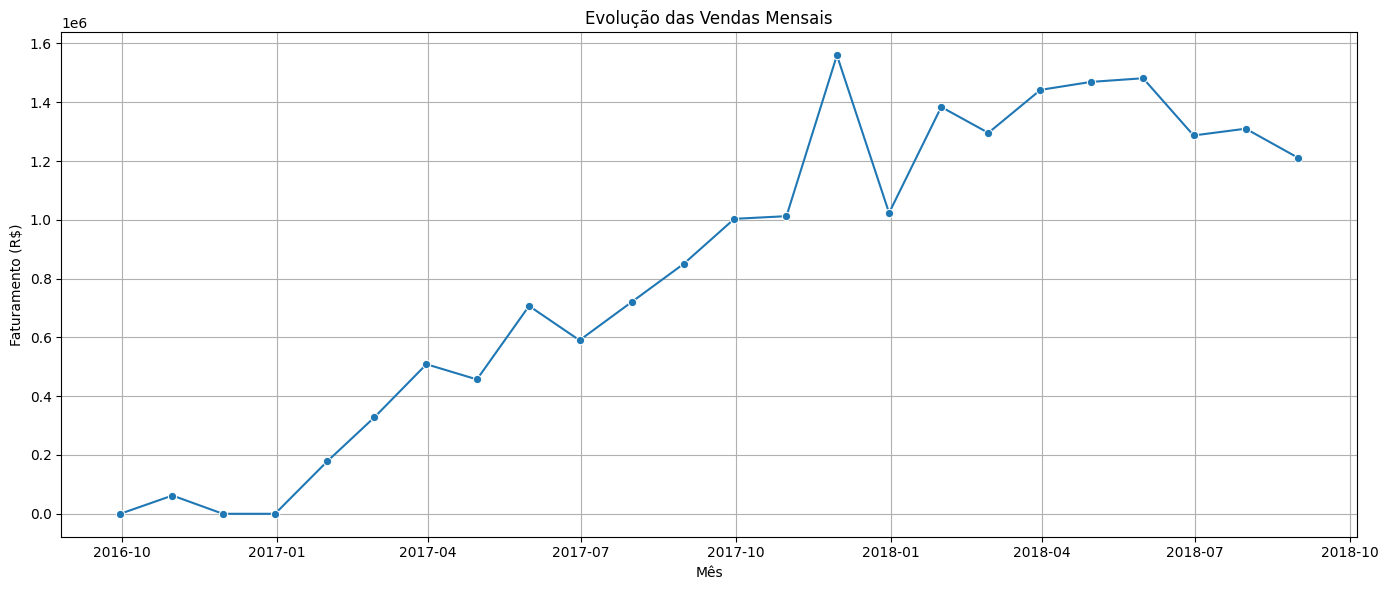

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

# Converter a data para datetime
base_geral_df['order_purchase_timestamp'] = pd.to_datetime(base_geral_df['order_purchase_timestamp'])

# Agrupar por mês e somar o valor dos pedidos
vendas_mensais = base_geral_df.groupby(pd.Grouper(key='order_purchase_timestamp', freq='M'))['payment_value'].sum().reset_index()

# Plot
plt.figure(figsize=(14,6))
sns.lineplot(data=vendas_mensais, x='order_purchase_timestamp', y='payment_value', marker='o')
plt.title("Evolução das Vendas Mensais")
plt.xlabel("Mês")
plt.ylabel("Faturamento (R$)")
plt.grid(True)
plt.tight_layout()
plt.show()

C:\Users\SCardos4\AppData\Local\Temp\ipykernel_29904\2971185470.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=vendas_por_estado, x='customer_state', y='payment_value', palette='viridis')


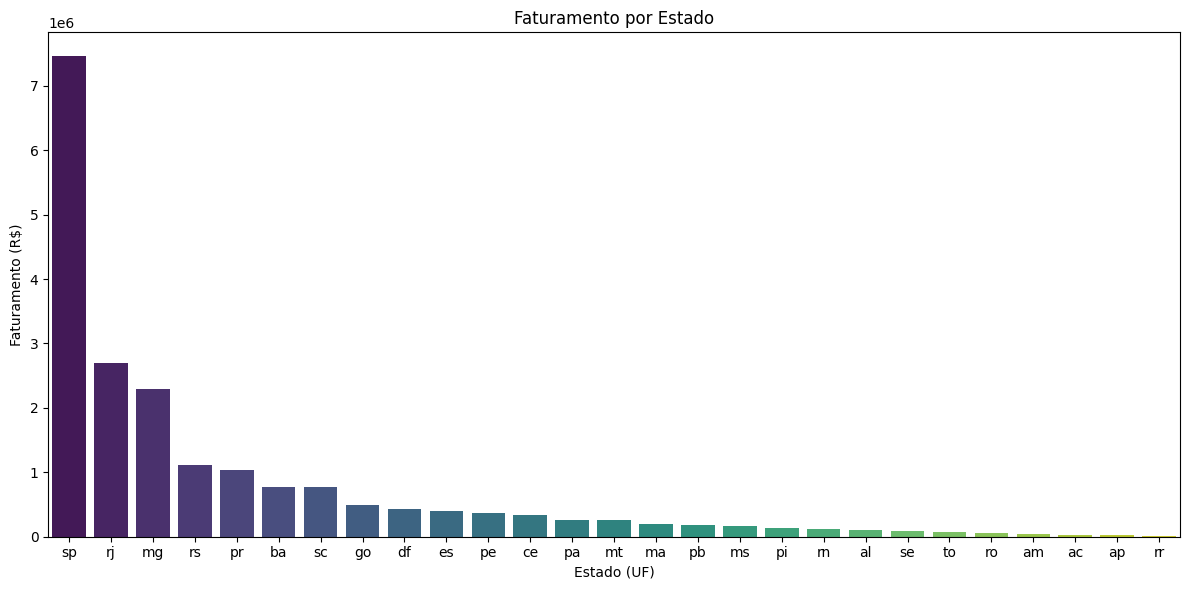

In [65]:
vendas_por_estado = base_geral_df.groupby('customer_state')['payment_value'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12,6))
sns.barplot(data=vendas_por_estado, x='customer_state', y='payment_value', palette='viridis')
plt.title('Faturamento por Estado')
plt.xlabel('Estado (UF)')
plt.ylabel('Faturamento (R$)')
plt.tight_layout()
plt.show()

C:\Users\SCardos4\AppData\Local\Temp\ipykernel_29904\1336297059.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=base_geral_df, x='review_score', y='tempo_entrega', palette='coolwarm')


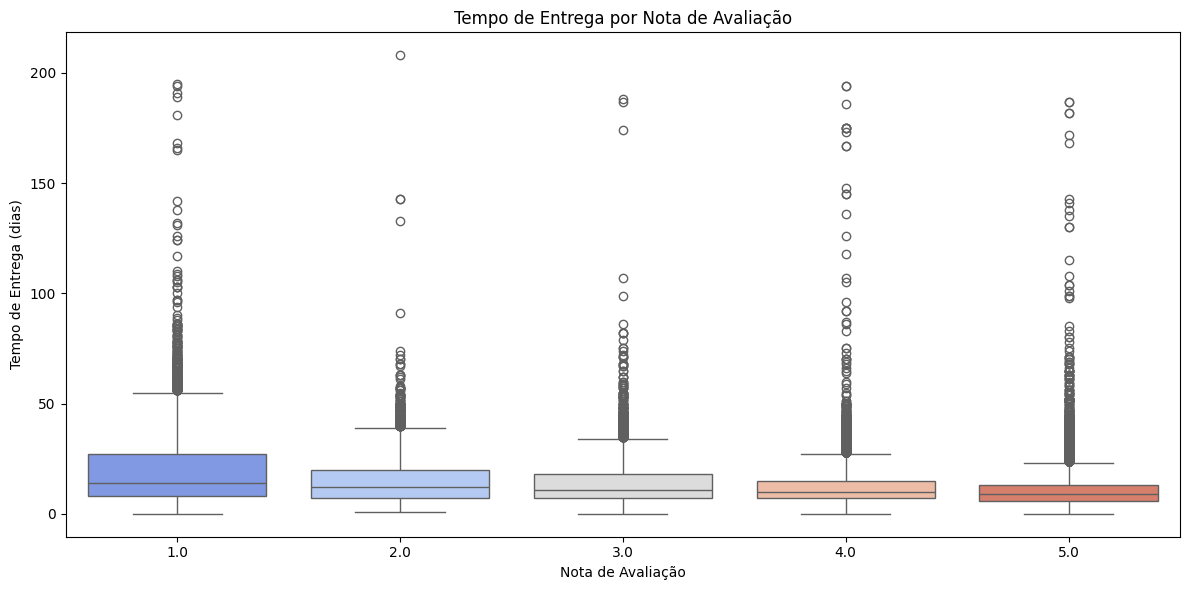

In [66]:
# Calcular tempo de entrega em dias
base_geral_df['order_delivered_customer_date'] = pd.to_datetime(base_geral_df['order_delivered_customer_date'])
base_geral_df['tempo_entrega'] = (base_geral_df['order_delivered_customer_date'] - base_geral_df['order_purchase_timestamp']).dt.days

plt.figure(figsize=(12,6))
sns.boxplot(data=base_geral_df, x='review_score', y='tempo_entrega', palette='coolwarm')
plt.title('Tempo de Entrega por Nota de Avaliação')
plt.xlabel('Nota de Avaliação')
plt.ylabel('Tempo de Entrega (dias)')
plt.tight_layout()
plt.show()

C:\Users\SCardos4\AppData\Local\Temp\ipykernel_29904\1147512037.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_vendas, x='seller_id', y='qtd_pedidos', palette='Blues_d')


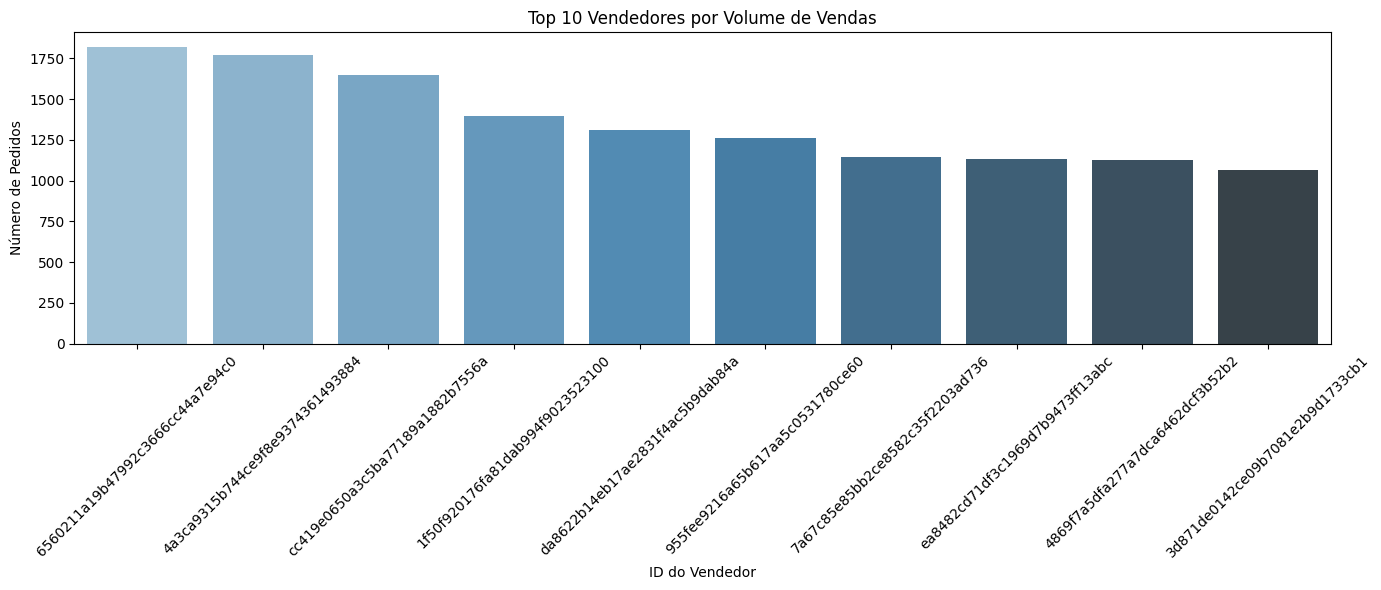

In [67]:
# Agrupando dados por vendedor
vendedores = base_geral_df.groupby('seller_id').agg({
    'order_id': 'nunique',
    'review_score': 'mean',
    'tempo_entrega': 'mean'
}).reset_index()

vendedores.columns = ['seller_id', 'qtd_pedidos', 'media_avaliacao', 'media_entrega']

# Top 10 por volume de pedidos
top_vendas = vendedores.sort_values('qtd_pedidos', ascending=False).head(10)

plt.figure(figsize=(14,6))
sns.barplot(data=top_vendas, x='seller_id', y='qtd_pedidos', palette='Blues_d')
plt.title('Top 10 Vendedores por Volume de Vendas')
plt.xlabel('ID do Vendedor')
plt.ylabel('Número de Pedidos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()